# Config

In [1]:
! git clone https://github.com/gcao88/scene-segmentation.git

Cloning into 'scene-segmentation'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 336 (delta 0), reused 2 (delta 0), pack-reused 330 (from 2)
Receiving objects: 100% (336/336), 1.24 GiB | 55.85 MiB/s, done.
Resolving deltas: 100% (150/150), done.
Updating files: 100% (110/110), done.


In [2]:
%cd /content/scene-segmentation
! pip install -q -r requirements.txt

/content/scene-segmentation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 145.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.5 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.


In [3]:
! git pull

remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 4), reused 16 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 135.68 MiB | 13.02 MiB/s, done.
From https://github.com/gcao88/scene-segmentation
   3cc4e50..3ac1d62  main       -> origin/main
Updating 3cc4e50..3ac1d62
Fast-forward
 .../segformer_boundary_bdou_bweighted_10e.pt       | Bin 0 -> 15337019 bytes
 .../segformer_boundary_bdou_bweighted_1e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_2e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_3e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_4e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_5e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_6e.pt        | Bin 0 -> 15336791 bytes
 .../segformer_boundary_bdou_bweighted_7e.pt   

In [4]:
import os

os.environ.setdefault("USE_TF", "0")

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import torch

# Import ADE20K

In [5]:
dataset_train = load_dataset("zhoubolei/scene_parse_150", split="train", trust_remote_code=True)
dataset_val = load_dataset("zhoubolei/scene_parse_150", split="validation", trust_remote_code=True)

print(f"Number of training samples: {len(dataset_train)}")
print(f"Number of validation samples: {len(dataset_val)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

scene_parse_150.py: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20210 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3352 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Number of training samples: 20210
Number of validation samples: 2000


In [6]:
! nvidia-smi

Tue May  5 04:12:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Import Segformer-B0

In [7]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
processor = SegformerImageProcessor.from_pretrained(model_name)
processor.do_reduce_labels = True  # 0 (unlabeled) -> 255 ignore; 1..150 -> 0..149
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

print(f"Loaded model: {model.config._name_or_path}")
print(f"hidden_sizes (per MiT stage): {model.config.hidden_sizes}")
print(f"F1 channels (boundary head input): {model.config.hidden_sizes[0]}")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loaded model: nvidia/segformer-b0-finetuned-ade-512-512
hidden_sizes (per MiT stage): [32, 64, 160, 256]
F1 channels (boundary head input): 32


# Check the ground truth boundary

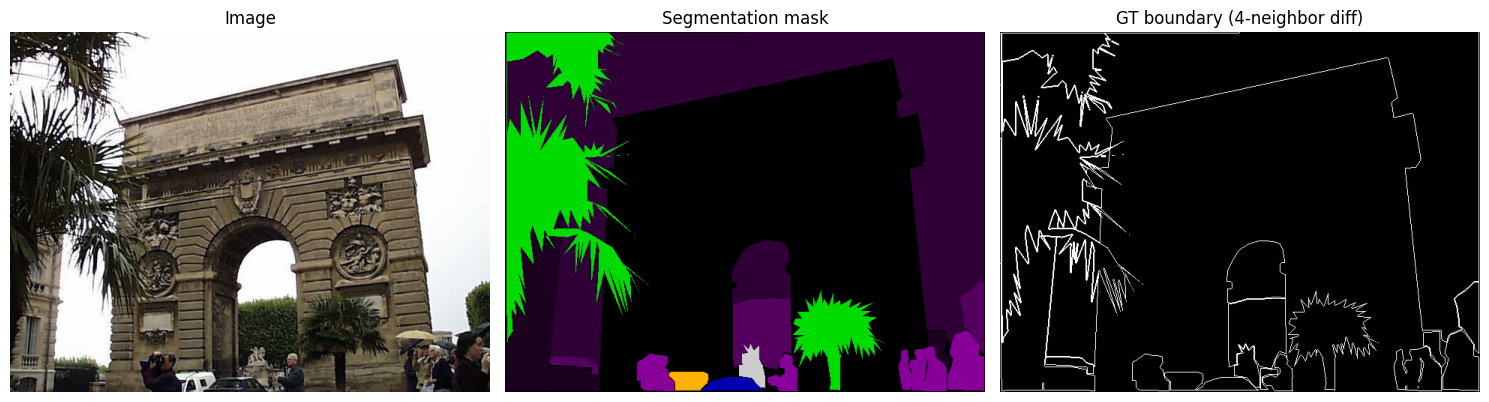

Boundary pixel ratio: 0.0421


In [ ]:
from aux_model import compute_boundary_target

sample = dataset_train[0]
image = sample["image"]
mask = np.array(sample["annotation"])
labels = torch.from_numpy(mask).long().unsqueeze(0)  # (1, H, W)
boundary = compute_boundary_target(labels, ignore_index=0).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image); axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(mask, cmap="nipy_spectral"); axes[1].set_title("Segmentation mask"); axes[1].axis("off")
axes[2].imshow(boundary, cmap="gray"); axes[2].set_title("GT boundary (4-neighbor diff)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

print(f"Boundary pixel ratio: {boundary.mean():.4f}")

# Train the boundary head model

In [ ]:
from aux_model import run_boundary_experiment

metrics, trained_model = run_boundary_experiment(
    dataset_train, dataset_val, processor, model,
    num_epochs=1,
    batch_size=16,
    learning_rate=5e-5,
    lambda_boundary=1,
    boundary_thicken=5,
    boundary_hidden=64,
    seg_loss_config='ce',
    max_train_samples=None,   # set a small int (e.g. 500) for quick smoke-test
    max_val_samples=None,
    save_dir='checkpoints',
    save_name='segformer_boundary_ce_v2_1e.pt',
    checkpoint_path=None,            # train from pretrained SegFormer
    compile_model=True,
)
print("boundary-aware:", metrics)


  boundary-aware (ce + boundary)


train:   0%|          | 0/1264 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/variables/functions.py:1946: UserWarning: Dynamo does not know how to trace the builtin `<unknown module>.SimpleNamespace.__new__.` This function is either a Python builtin (e.g. _warnings.warn) or a third-party C/C++ Python extension (perhaps created with pybind).
If it is a Python builtin, please file an issue on GitHub so the PyTorch team can add support for it and see the next case for a workaround.
If it is a third-party C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more details) or, if it is traceable, use `torch.compiler.allow_in_graph`.
  torch._dynamo.utils.warn_once(explanation + "\n" + "\n".join(hints))
W0503 04:24:19.350000 8963 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode
eval: 100%|██████████| 125/125 [03:21<00:00,  1

  epoch 1: train_loss=1.3240  {'mIoU': 0.35811278223991394, 'BF1@3': 0.4556189591165012, 'BF1@5': 0.562307418840731, 'BF1@9': 0.6823935588480426, 'BF1@12': 0.7367483926072217, 'BIoU': 0.24338007572465808}
  saved -> checkpoints/segformer_boundary_ce_v2_1e.pt
boundary-aware: {'mIoU': 0.35811278223991394, 'BF1@3': 0.4556189591165012, 'BF1@5': 0.562307418840731, 'BF1@9': 0.6823935588480426, 'BF1@12': 0.7367483926072217, 'BIoU': 0.24338007572465808}


In [10]:
from run_experiments import print_results_table

print_results_table({
    'ce + boundary-headv2-1e': metrics
})


Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
ce + boundary-headv2-1e     0.3581     0.4556     0.5623     0.6824     0.7367     0.2434


# Resume training for next epochs

In [ ]:
from aux_model import run_boundary_experiment

metrics, trained_model = run_boundary_experiment(
    dataset_train, dataset_val, processor, model,
    num_epochs=1,
    batch_size=16,
    learning_rate=5e-5,
    lambda_boundary=1,
    boundary_thicken=5,
    boundary_hidden=64,
    seg_loss_config='ce',
    max_train_samples=None,
    max_val_samples=None,
    save_dir='checkpoints',
    save_name='segformer_boundary_ce_v2_10e.pt',
    checkpoint_path='checkpoints/segformer_boundary_ce_v2_9e.pt',
    compile_model=True,
)


  boundary-aware (ce + boundary)
  [resume] loaded weights from checkpoints/segformer_boundary_ce_v2_9e.pt


eval: 100%|██████████| 125/125 [02:42<00:00,  1.30s/it]


  epoch 1: train_loss=1.1349  {'mIoU': 0.3633292019367218, 'BF1@3': 0.46238500493665136, 'BF1@5': 0.5679170913464664, 'BF1@9': 0.6855393772998527, 'BF1@12': 0.7388419336989352, 'BIoU': 0.247411616031767}
  saved -> checkpoints/segformer_boundary_ce_v2_10e.pt


In [28]:
from run_experiments import print_results_table

print_results_table({
    'ce + boundary-headv2-10e': metrics
})


Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
ce + boundary-headv2-10e     0.3633     0.4624     0.5679     0.6855     0.7388     0.2474


In [25]:
metrics, trained_model = run_boundary_experiment(
    dataset_train, dataset_val, processor, model,
    num_epochs=1,
    batch_size=16,
    learning_rate=5e-5,
    lambda_boundary=1,
    boundary_thicken=5,
    boundary_hidden=64,
    seg_loss_config='ce',
    max_train_samples=None,
    max_val_samples=None,
    save_dir='checkpoints',
    save_name='segformer_boundary_ce_v2_9e.pt',
    checkpoint_path='checkpoints/segformer_boundary_ce_v2_8e.pt',
    compile_model=True,
)


  boundary-aware (ce + boundary)
  [resume] loaded weights from checkpoints/segformer_boundary_ce_v2_8e.pt


eval: 100%|██████████| 125/125 [02:41<00:00,  1.29s/it]


  epoch 1: train_loss=1.1441  {'mIoU': 0.3650064766407013, 'BF1@3': 0.46381863136978885, 'BF1@5': 0.5690093614951971, 'BF1@9': 0.6870303093960054, 'BF1@12': 0.7401353944491116, 'BIoU': 0.24875450697931825}
  saved -> checkpoints/segformer_boundary_ce_v2_9e.pt


In [26]:
from run_experiments import print_results_table

print_results_table({
    'ce + boundary-headv2-9e': metrics
})


Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
ce + boundary-headv2-9e     0.3650     0.4638     0.5690     0.6870     0.7401     0.2488
